In [35]:
from pathlib import Path
import tomllib
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from nbtools import normhist, normhist2d

In [36]:
auto_plot_style()

In [37]:
rbins     = np.linspace(  0, 16, 81)
xybins    = np.linspace(-16, 16, 81)
drbins_bb = np.linspace(  0, 12, 81)
drbins_nn = np.linspace(  0, 3, 81)

In [42]:
path = Path("../data/pcolina/6x6/0.50/10um/")
reco = path / "reco.h5"
imgs = path / "images_test.csv"
conf = tomllib.loads(open(path / "run.conf").read())
print(conf)

reco = pd.read_hdf(reco)
imgs = pd.read_csv(imgs , sep=" ", header=0)
imgs.insert(3, "r0", (imgs.x0**2 + imgs.y0**2)**0.5)
#ave  = (imgs.img_4_4 + imgs.img_4_5 + imgs.img_5_4 + imgs.img_5_5) / 4
ave  = imgs.img_2_2
nie  = imgs.filter(regex="w_*").values.sum(axis=1)
ly   = ave / nie
data = imgs.iloc[:, :4].assign(light=ave, nie=nie, ly=ly)

{'n_events': 1000000, 'output': '../data/pcolina/6x6/0.50/10um/', 'geometry': {'buffer': 3.0, 'wire_plane': {'wire_pitch': 5.0, 'wire_r': 0.005, 'wire_rotation': 45.0, 'n_wires': 14}, 'sipm_plane': {'sipm_size': 6.0, 'sipm_area': 34.8075, 'sipm_gap': 0.5, 'n_sipms_side': 5}, 'el_gap': {'el_r': 16.0, 'el_gap_front': 5.0, 'el_gap_back': 5.0}}, 'sim_params': {'dep_energy': 5898.75, 'w_i': 15.6, 'light_yield': 30.0, 'el_range': 0.04, 'cloud_r': 0.02, 'fano_factor': 0.05}}


In [43]:
data

,event,x0,y0,r0,light,nie,ly
0,0,-12.282980,-4.738420,13.165266,48,379,0.126649
1,1,-9.432777,-1.528080,9.555747,134,379,0.353562
2,2,6.973291,11.560125,13.500492,53,380,0.139474
3,3,5.742168,-3.370426,6.658248,177,378,0.468254
4,4,7.222781,-4.390593,8.452566,169,378,0.447090
...,...,...,...,...,...,...,...
999995,999995,-11.448569,9.294746,14.746594,10,379,0.026385
999996,999996,-10.550058,7.704357,13.063722,59,379,0.155673
999997,999997,-11.542366,-7.035041,13.517323,73,379,0.192612
999998,999998,8.773004,-1.940676,8.985089,141,380,0.371053


/tmp/ipykernel_7155/3267084915.py:6: RuntimeWarning: invalid value encountered in divide
  l = l/n


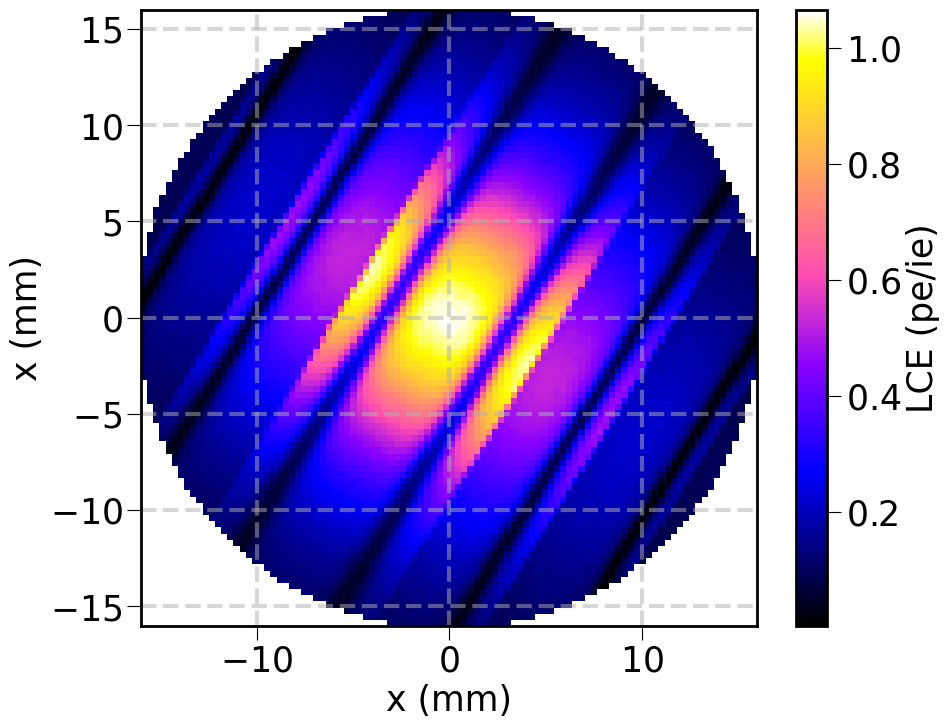

In [44]:
bins   = np.linspace(-16, 16, 101)
extent = (bins[0], bins[-1])*2

n = np.histogram2d(data.x0, data.y0, bins            )[0]
l = np.histogram2d(data.x0, data.y0, bins, weights=ly)[0]
l = l/n
plt.imshow(l, extent=extent, origin="lower")
plt.xlabel("x (mm)")
plt.ylabel("x (mm)")
plt.colorbar().set_label("LCE (pe/ie)")
plt.gca().set_aspect(1)
plt.grid()